In [ ]:
# === MASTER CELL ===
# Lädt alle Daten und Bibliotheken
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/q_fit_results.csv")

In [32]:
def get_type(name):
    name = str(name).upper()

    if name.startswith("NGC"):
        return "NGC"
    elif name.startswith("UGC") or name.startswith("UGCA"):
        return "UGC"
    elif name.startswith("DDO") or name.startswith("D"):
        return "Dwarf"
    elif name.startswith("IC"):
        return "IC"
    elif name.startswith("ESO"):
        return "ESO"
    elif name.startswith("F"):
        return "LSB"
    else:
        return "Other"

df["type"] = df["filename"].apply(get_type)

print(df[["filename", "type", "q"]].head())

              filename type         q
0   UGCA444_rotmod.dat  UGC  3.000000
1   UGCA442_rotmod.dat  UGC  0.485413
2   UGCA281_rotmod.dat  UGC  0.581791
3  UGC12732_rotmod.dat  UGC  3.000000
4  UGC12632_rotmod.dat  UGC  0.679549


In [29]:
def get_type(name):
    name = name.upper()

    if name.startswith("NGC"):
        return "NGC"
    elif name.startswith("UGC") or name.startswith("UGCA"):
        return "UGC"
    elif name.startswith("DDO") or name.startswith("D"):
        return "Dwarf"
    elif name.startswith("IC"):
        return "IC"
    elif name.startswith("ESO"):
        return "ESO"
    elif name.startswith("F"):
        return "LSB"
    else:
        return "Other"

df["type"] = df["filename"].apply(get_type)

print(df[["filename", "type"]].head())

              filename type
0   UGCA444_rotmod.dat  UGC
1   UGCA442_rotmod.dat  UGC
2   UGCA281_rotmod.dat  UGC
3  UGC12732_rotmod.dat  UGC
4  UGC12632_rotmod.dat  UGC


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv(/content/.config/q_fit_results.csv)

print(df.head())
print(df.columns)

SyntaxError: invalid syntax (765940020.py, line 5)

In [25]:
import pandas as pd

df = pd.read_csv("/content/q_fit_results.csv")

print(df.head())

              filename         p         q       MSE  n_points
0   UGCA444_rotmod.dat  1.459703  3.000000  0.003141        36
1   UGCA442_rotmod.dat  2.044649  0.485413  0.000330         8
2   UGCA281_rotmod.dat  1.943306  0.581791  0.000616         7
3  UGC12732_rotmod.dat  0.781112  3.000000  0.001713        16
4  UGC12632_rotmod.dat  1.273916  0.679549  0.001109        15


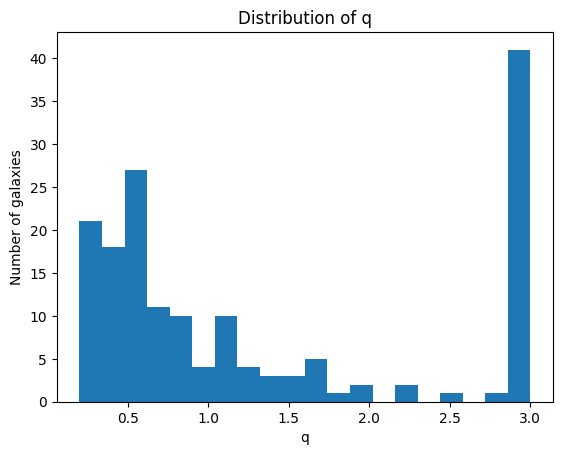

In [26]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["q"], bins=20)

plt.xlabel("q")
plt.ylabel("Number of galaxies")
plt.title("Distribution of q")

plt.savefig("q_histogram.png")
plt.show()

<Figure size 640x480 with 0 Axes>

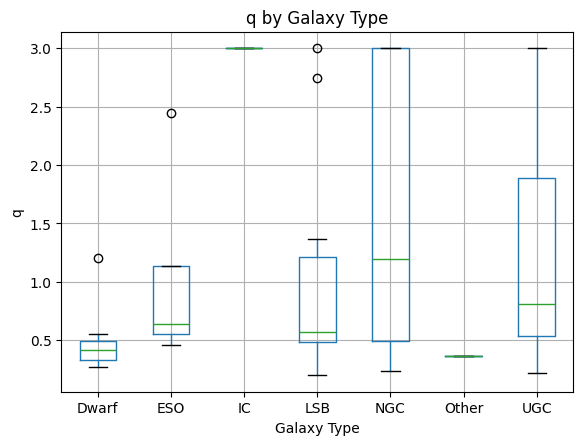

In [30]:
plt.figure()
df.boxplot(column="q", by="type")

plt.title("q by Galaxy Type")
plt.suptitle("")
plt.xlabel("Galaxy Type")
plt.ylabel("q")

plt.savefig("/content/q_by_type.png")
plt.show()

In [31]:
df.groupby("type")["q"].mean()

,q
type,
Dwarf,0.508745
ESO,1.046774
IC,3.000000
LSB,0.957716
NGC,1.604654
Other,0.362564
UGC,1.257162


In [33]:
peak = (df["q"] < 1.2).mean()
diffuse = (df["q"] > 2.5).mean()
transition = ((df["q"] >= 1.2) & (df["q"] < 2.5)).mean()

print("Peak:", peak)
print("Diffuse:", diffuse)
print("Transition:", transition)

Peak: 0.6219512195121951
Diffuse: 0.25609756097560976
Transition: 0.12195121951219512


In [35]:
type_means = df.groupby("type")["q"].mean().sort_values()
print(type_means)

type
Other    0.362564
Dwarf    0.508745
LSB      0.957716
ESO      1.046774
UGC      1.257162
NGC      1.604654
IC       3.000000
Name: q, dtype: float64


In [37]:
type_means.to_csv("/content/q_mean_by_type.csv")

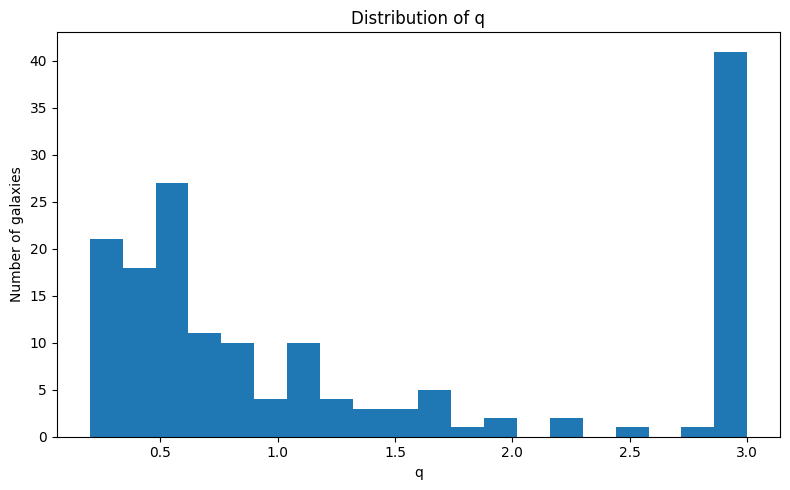

In [38]:
plt.figure(figsize=(8,5))
plt.hist(df["q"], bins=20)

plt.xlabel("q")
plt.ylabel("Number of galaxies")
plt.title("Distribution of q")
plt.tight_layout()

plt.savefig("/content/q_histogram.png", dpi=300)
plt.show()

<Figure size 900x500 with 0 Axes>

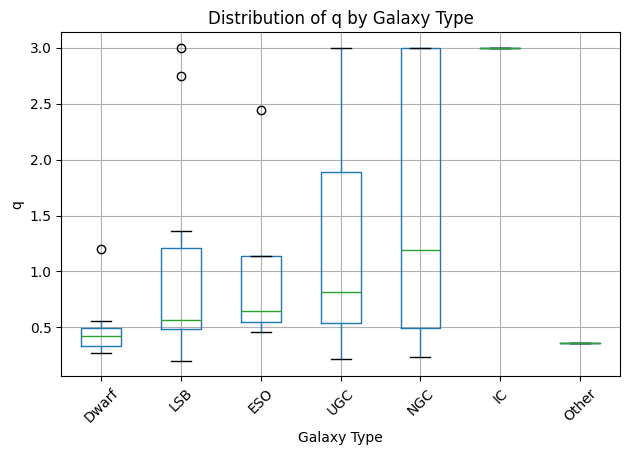

In [39]:
order = ["Dwarf", "LSB", "ESO", "UGC", "NGC", "IC", "Other"]
df["type"] = pd.Categorical(df["type"], categories=order, ordered=True)

plt.figure(figsize=(9,5))
df.boxplot(column="q", by="type")

plt.title("Distribution of q by Galaxy Type")
plt.suptitle("")
plt.xlabel("Galaxy Type")
plt.ylabel("q")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("/content/q_by_type.png", dpi=300)
plt.show()

In [40]:
summary = pd.DataFrame({
    "quantity": ["Peak fraction", "Diffuse fraction", "Transition fraction"],
    "value": [peak, diffuse, transition]
})

summary.to_csv("/content/regime_summary.csv", index=False)
print(summary)

              quantity     value
0        Peak fraction  0.621951
1     Diffuse fraction  0.256098
2  Transition fraction  0.121951


In [41]:
print(os.listdir("/content"))

['.config', 'q_by_type.png', 'q_mean_by_type.csv', 'sample_data', 'drive', 'q_fit_results.csv', 'regime_summary.csv', 'q_histogram.png']
